In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
# This helps to run on GPU device 
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
data = pd.read_csv("/Users/sushil0711/Downloads/Tesla.csv - Tesla.csv.csv", 
                     index_col=0, parse_dates=True)
data.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [4]:
data.shape

(1692, 6)

In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1692 entries, 2010-06-29 to 2017-03-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1692 non-null   float64
 1   High       1692 non-null   float64
 2   Low        1692 non-null   float64
 3   Close      1692 non-null   float64
 4   Volume     1692 non-null   int64  
 5   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 92.5 KB


In [6]:
data.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [7]:
data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [8]:
data.drop(["Adj Close"], axis = 1, inplace = True)

In [9]:
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900


In [10]:
X = data.drop(["Close"], axis = 1).values
y = data["Close"].values

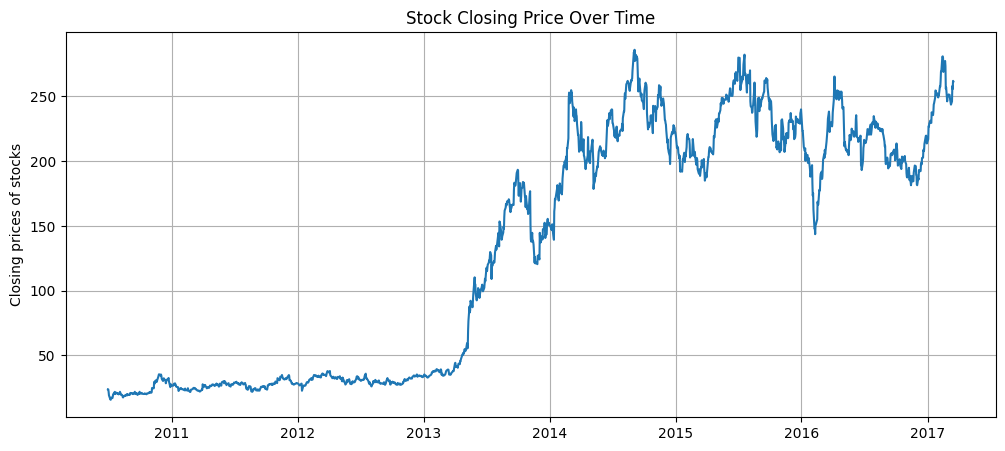

In [11]:
plt.figure(figsize=(12,5))
plt.title('Stock Closing Price Over Time')
plt.ylabel('Closing prices of stocks')
plt.grid(True)
plt.plot(data['Close'])
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [13]:
from sklearn.preprocessing import MinMaxScaler
X_scaler = MinMaxScaler(feature_range = (-1,1))
y_scaler = MinMaxScaler(feature_range = (-1,1))
X_train = X_scaler.fit_transform(X_train)
y_train = y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
X_test = X_scaler.transform(X_test)
y_test = y_scaler.transform(y_test.reshape(-1,1)).flatten()

In [14]:
def createSeq(X, y, ws):
    x_seq = []
    y_seq = [] 

    for i in range(len(X) - ws - 1):
        x_seq.append(X[i : i + ws])
        y_seq.append(y[i + ws])

    return x_seq, y_seq



window_size = 60 
X_train_seq, y_train_seq = createSeq(X_train, y_train, window_size)


In [15]:
X_train = torch.FloatTensor(X_train_seq)
y_train = torch.FloatTensor(y_train_seq)

/var/folders/jq/rpx_7rp94yxdcftrl65sdwth0000gn/T/ipykernel_34483/1210332201.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  X_train = torch.FloatTensor(X_train_seq)


In [16]:
train_data = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_data, 
    batch_size = 32, 
    shuffle=True
)

In [17]:
class LSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz, out_sz):
        super().__init__()

        self.hidden_sz = hidden_sz

        self.lstm = nn.LSTM(input_sz, hidden_sz, batch_first = True)
        self.linear = nn.Linear(hidden_sz, out_sz)

    def forward(self, seq):

        h0 = torch.zeros(1,seq.size(0), self.hidden_sz, device = device)
        c0 = torch.zeros(1,seq.size(0), self.hidden_sz, device = device) 

        lstm_out, _ = self.lstm(seq, (h0, c0))

        pred = self.linear(lstm_out[:, -1, :])

        return pred 

In [18]:
torch.manual_seed(101)
model = LSTM(4, 100, 1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
model

LSTM(
  (lstm): LSTM(4, 100, batch_first=True)
  (linear): Linear(in_features=100, out_features=1, bias=True)
)

In [19]:
# Train the Model  
epochs = 100 

import time
start_time = time.time()

for epoch in range(epochs):

    model.train()

    for seq, y_train in train_loader:

        seq = seq.to(device)
        y_train = y_train.to(device)

        optimizer.zero_grad()
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train.unsqueeze(1))
        loss.backward()
        optimizer.step()

    
    print(f'Epoch: {epoch+1:2} Loss: {loss.item():10.8f}')
    

print(f'\nDuration: {time.time() - start_time:.0f} seconds')

        

Epoch:  1 Loss: 0.00948465
Epoch:  2 Loss: 0.00355738
Epoch:  3 Loss: 0.00312350
Epoch:  4 Loss: 0.00313942
Epoch:  5 Loss: 0.00236433
Epoch:  6 Loss: 0.00266243
Epoch:  7 Loss: 0.00091725
Epoch:  8 Loss: 0.00306143
Epoch:  9 Loss: 0.00132769
Epoch: 10 Loss: 0.00145530
Epoch: 11 Loss: 0.00196379
Epoch: 12 Loss: 0.00197646
Epoch: 13 Loss: 0.00256646
Epoch: 14 Loss: 0.00173242
Epoch: 15 Loss: 0.00336618
Epoch: 16 Loss: 0.00462210
Epoch: 17 Loss: 0.00819982
Epoch: 18 Loss: 0.00024276
Epoch: 19 Loss: 0.00570861
Epoch: 20 Loss: 0.00490131
Epoch: 21 Loss: 0.00266209
Epoch: 22 Loss: 0.00095973
Epoch: 23 Loss: 0.00140391
Epoch: 24 Loss: 0.00138500
Epoch: 25 Loss: 0.00117152
Epoch: 26 Loss: 0.00152530
Epoch: 27 Loss: 0.00170344
Epoch: 28 Loss: 0.00016724
Epoch: 29 Loss: 0.00283867
Epoch: 30 Loss: 0.00256979
Epoch: 31 Loss: 0.00015877
Epoch: 32 Loss: 0.00373249
Epoch: 33 Loss: 0.00078065
Epoch: 34 Loss: 0.00192108
Epoch: 35 Loss: 0.00166468
Epoch: 36 Loss: 0.00115296
Epoch: 37 Loss: 0.00036980
E

In [20]:
X_test_seq, y_test_seq = createSeq(X_test, y_test, window_size)

X_test_seq = torch.FloatTensor(X_test_seq)
y_test_seq = torch.FloatTensor(y_test_seq)

In [21]:
# Test Evaluation

model.eval()

test_preds = []

with torch.no_grad():

    for seq in X_test_seq:

        seq = seq.unsqueeze(0).to(device)

        y_pred = model(seq)

        test_preds.append(y_pred.item())

In [22]:
test_preds

[0.03447994217276573,
 0.01988191530108452,
 0.006566129624843597,
 0.04789197817444801,
 0.006000779569149017,
 0.07262687385082245,
 0.09739647805690765,
 0.14192235469818115,
 0.10310095548629761,
 0.17822538316249847,
 0.1965186595916748,
 0.1657140702009201,
 0.239439457654953,
 0.2899695336818695,
 0.32105204463005066,
 0.2970553934574127,
 0.26040396094322205,
 0.3155222237110138,
 0.38926902413368225,
 0.3964404761791229,
 0.4109356105327606,
 0.4196087121963501,
 0.4311007559299469,
 0.4305056035518646,
 0.4871077239513397,
 0.4897547662258148,
 0.5295110940933228,
 0.5574527978897095,
 0.6127849817276001,
 0.6546489000320435,
 0.6370836496353149,
 0.5850902199745178,
 0.5345943570137024,
 0.6221034526824951,
 0.5985508561134338,
 0.6271405220031738,
 0.611242413520813,
 0.6917928457260132,
 0.7323248386383057,
 0.7339586615562439,
 0.8395218253135681,
 0.8261299133300781,
 0.7697599530220032,
 0.7487941980361938,
 0.7099820375442505,
 0.7534135580062866,
 0.7643470764160156,


In [23]:
true_predictions = y_scaler.inverse_transform(np.array(test_preds).reshape(-1, 1))
actual = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
true_predictions

array([[155.57893444],
       [153.60644898],
       [151.80721996],
       [157.39116881],
       [151.73082986],
       [160.73334802],
       [164.08021705],
       [170.09655371],
       [164.85100607],
       [175.00181907],
       [177.47360667],
       [173.31129041],
       [183.2730651 ],
       [190.1006892 ],
       [194.30055822],
       [191.0581306 ],
       [186.10578887],
       [193.55336879],
       [203.51803679],
       [204.48704343],
       [206.44562604],
       [207.61753558],
       [209.17034058],
       [209.08992359],
       [216.73800235],
       [217.09567072],
       [222.46754592],
       [226.24302906],
       [233.71951399],
       [239.37616682],
       [237.00275011],
       [229.97739766],
       [223.15439643],
       [234.97862583],
       [231.79619887],
       [235.65923466],
       [233.51108217],
       [244.39505693],
       [249.87173999],
       [250.09250215],
       [264.35619731],
       [262.54668211],
       [254.92997282],
       [252

In [24]:
results = pd.DataFrame({
    "Actual_data" : actual, 
    "prediction" : true_predictions.flatten() 
})
results

,Actual_data,prediction
0,148.250000,155.578934
1,143.669998,153.606449
2,150.470001,151.807220
3,151.039993,157.391169
4,155.169998,151.730830
...,...,...
273,243.690005,245.774138
274,246.169997,245.280071
275,258.000001,246.156435
276,255.729995,253.657629


In [25]:
model.eval()

train_preds = []
train_targets = []

with torch.no_grad():
    for seq, target in train_loader:

        seq = seq.to(device)
        target = target.to(device)

        y_pred = model(seq)

        train_preds.extend(y_pred.cpu().numpy().flatten())
        train_targets.extend(target.cpu().numpy().flatten())

In [26]:
train_preds = y_scaler.inverse_transform(
    np.array(train_preds).reshape(-1, 1)
)

train_targets = y_scaler.inverse_transform(
    np.array(train_targets).reshape(-1, 1) 
)

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
train_mae = mean_absolute_error(train_targets, train_preds)

print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)

test_rmse = np.sqrt(mean_squared_error(actual, true_predictions))
test_mae = mean_absolute_error(actual, true_predictions)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)

Train RMSE: 4.7164139175542275
Train MAE: 3.0361287593841553
Test RMSE: 5.992914212618282
Test MAE: 4.589121635526978


In [28]:
results.index = data.index[-len(results):]

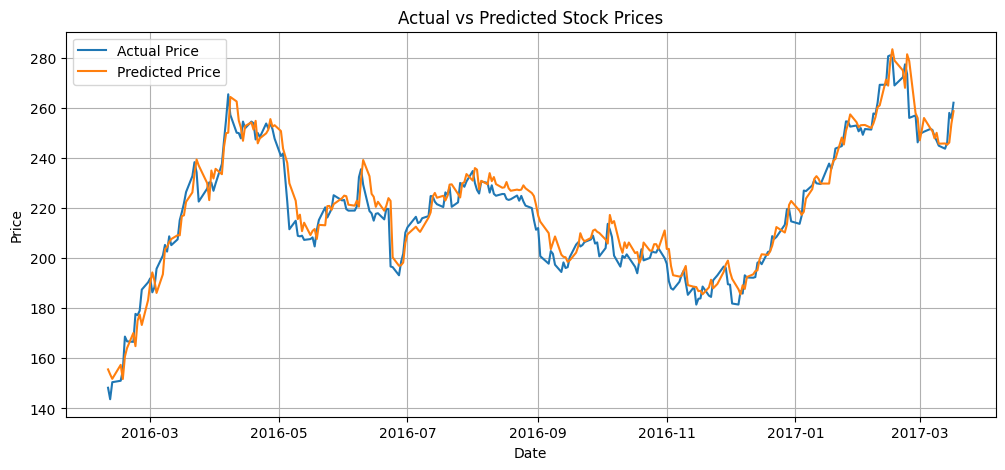

In [29]:
plt.figure(figsize=(12,5))

plt.plot(results.index, results["Actual_data"].values, label="Actual Price")
plt.plot(results.index, results["prediction"].values, label="Predicted Price")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)
plt.legend()
plt.show()